# Multimodal Cardiac Fusion Model — ECG + Echocardiogram
**Task:** 6-class structural heart disease classification  
**Architecture:** 1D-ResNet (ECG) → Phase Tokenizer + ResNet50 (Echo) → Cycle Tokenizer → 2× Cross-Attention → MLP Head  
**Training:** Stage 1 (frozen encoders, head-only) → Stage 2 (end-to-end fine-tune with differential LRs)  
**XAI:** Electromechanical Attribution Maps (cross-attention weights), Grad-CAM on echo, Integrated Gradients on ECG

## 0 · Environment Check
Verify GPU availability and VRAM before loading the model.  
This notebook requires a CUDA-capable GPU with at least 6 GB VRAM (RTX 4060 Laptop or Colab T4).

In [1]:
import torch

print(f"PyTorch   : {torch.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU       : {torch.cuda.get_device_name(0)}")
    print(f"VRAM      : {props.total_memory / 1e9:.1f} GB")
    print(f"VRAM free : {(props.total_memory - torch.cuda.memory_reserved(0)) / 1e9:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")

PyTorch   : 2.11.0+cu128
CUDA avail: True
GPU       : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM      : 8.6 GB
VRAM free : 8.6 GB

Using device: cuda


## 1 · Configuration

Central config block — all hyperparameters live here.

**Multi-task setup:**
- Two binary classification tasks: **structural disease** (normal vs disease) and **arrhythmia** (normal rhythm vs arrhythmia)
- `LAMBDA_STRUCT = 1.0` — structural disease is the primary task (full weight)
- `LAMBDA_ARR = 0.5` — arrhythmia is the auxiliary task (half weight). Its role is to force the ECG encoder to learn meaningful electrical features, which in turn improves the shared fusion representation

**Why multi-task?**
- ECG dominates arrhythmia detection → the ECG encoder must learn useful features to solve this task
- Echo dominates structural detection → the echo encoder must learn useful features to solve this task
- The shared cross-attention fusion must integrate both modalities to solve both tasks simultaneously
- Neither modality can be ignored — this is what makes the fusion genuinely multimodal

**Architecture choices:**
- `PROJ_DIM = 96` — shared embedding space, kept small to prevent overfitting on ~3200 training samples
- `ATTN_LAYERS = 2` — two stacked cross-attention layers for iterative cross-modal alignment
- `MLP_DROPOUT = 0.5` — aggressive dropout to regularise the small dataset

**Training:**
- Stage 1 (frozen encoders) is skipped — it plateaued at 0.22 F1 on this dataset
- End-to-end training from scratch with differential learning rates
- Best model saved by **combined macro-F1** (average of structural F1 and arrhythmia F1)

In [9]:
import os, random
import numpy as np
import torch

# ── Paths ─────────────────────────────────────────────────────────────────────
CACHE_DIR  = r"C:\Users\anwme\Desktop\Datasets\cache"
OUTPUT_DIR = r"C:\Users\anwme\Desktop\Datasets\model_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Data ──────────────────────────────────────────────────────────────────────
ECG_LEADS   = 12
ECG_LEN     = 5000
ECHO_SIZE   = 224
ECHO_FRAMES = 3

# ── Task ──────────────────────────────────────────────────────────────────────
NUM_CLASSES_STRUCT = 2
NUM_CLASSES_ARR    = 2
STRUCT_CLASSES     = ['normal', 'structural_disease']
ARR_CLASSES        = ['normal_rhythm', 'arrhythmia']

LAMBDA_STRUCT = 1.0
LAMBDA_ARR    = 0.5

# ── Model ─────────────────────────────────────────────────────────────────────
ECG_BASE_DIM  = 256
ECHO_BASE_DIM = 2048
PROJ_DIM      = 96
ATTN_HEADS    = 4
ATTN_LAYERS   = 2
ATTN_DROPOUT  = 0.1
MLP_DROPOUT   = 0.5

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 16
S2_EPOCHS  = 30
S2_LR      = 3e-5
PATIENCE   = 8
SEED       = 42

# ── Reproducibility ───────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"Config OK")

Device: cuda
Config OK


## 2 · Dataset & DataLoaders

Loads the preprocessed `.npz` cache files and remaps labels to binary for both tasks.

**Label mapping:**
- **Structural:** `normal` → 0, everything else (ischemic, heart failure, cardiomyopathy, valve disease, pericardial disease) → 1
- **Arrhythmia:** `normal` → 0, everything else (atrial fibrillation, ventricular arrhythmia, conduction disorder, tachycardia, bradycardia, other) → 1

**Each sample returns 4 tensors:**
- ECG: `(12, 5000)` float32 — 12 leads × 5000 timepoints, z-score normalised per lead
- Echo: `(3, 224, 224)` float32 — 3 cardiac phases (ED / Mid / ES), ImageNet-style normalisation
- Structural label: 0 or 1
- Arrhythmia label: 0 or 1

**Class imbalance handling:**
- `WeightedRandomSampler` oversamples structurally-normal patients 4× during training, so each batch sees roughly balanced structural classes
- Note: `shuffle=True` is removed when using a sampler — they're mutually exclusive

**Augmentation (training only):**
- ECG: amplitude jitter (±20%), additive Gaussian noise, random time shift (up to 1s), random lead dropout (zeroes 1–2 leads)
- Echo: random horizontal flip, random brightness/contrast adjustment

`num_workers=0` is required on Windows to avoid subprocess deadlocks in Jupyter.

In [10]:
import json
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

with open(os.path.join(CACHE_DIR, 'classes.json')) as f:
    meta = json.load(f)
print(f"Original 6 classes: {meta['classes']}")
print(f"Binary structural : {STRUCT_CLASSES}")
print(f"Binary arrhythmia : {ARR_CLASSES}")


class CardiacDataset(Dataset):
    def __init__(self, npz_path, augment=False):
        data         = np.load(npz_path, mmap_mode='r')
        self.ecg     = data['ecg']
        self.echo    = data['echo']
        self.augment = augment
        self.echo_mean = torch.tensor([0.449], dtype=torch.float32)
        self.echo_std  = torch.tensor([0.226], dtype=torch.float32)

        # Both binary labels
        self.labels_struct = data['label_struct_bin'].copy()
        self.labels_arr    = data['label_arr_bin'].copy()

        ns = np.bincount(self.labels_struct, minlength=2)
        na = np.bincount(self.labels_arr, minlength=2)
        print(f"  Structural: normal={ns[0]}  disease={ns[1]}  ratio=1:{ns[1]/max(ns[0],1):.1f}")
        print(f"  Arrhythmia: normal={na[0]}  arrhythmia={na[1]}  ratio=1:{na[1]/max(na[0],1):.1f}")

    def __len__(self):
        return len(self.labels_struct)

    def _augment_ecg(self, ecg):
        ecg = ecg * np.random.uniform(0.8, 1.2)
        ecg = ecg + np.random.randn(*ecg.shape).astype(np.float32) * 0.05
        shift = np.random.randint(0, 500)
        ecg = np.concatenate([ecg[:, shift:],
                               np.zeros((ecg.shape[0], shift), dtype=np.float32)], axis=1)
        if np.random.rand() > 0.5:
            n_drop = np.random.randint(1, 3)
            drop_idx = np.random.choice(12, n_drop, replace=False)
            ecg[drop_idx] = 0
        return ecg

    def _augment_echo(self, echo):
        if np.random.rand() > 0.5:
            echo = echo[:, :, ::-1].copy()
        if np.random.rand() > 0.5:
            gain = np.random.uniform(0.8, 1.2)
            bias = np.random.uniform(-15, 15)
            echo = np.clip(echo.astype(np.float32) * gain + bias, 0, 255).astype(np.uint8)
        return echo

    def __getitem__(self, idx):
        ecg  = self.ecg[idx].copy().astype(np.float32)
        echo = self.echo[idx].copy()
        lbl_s = int(self.labels_struct[idx])
        lbl_a = int(self.labels_arr[idx])

        ecg = np.nan_to_num(ecg, nan=0.0, posinf=8.0, neginf=-8.0)
        ecg = np.clip(ecg, -8.0, 8.0)

        if self.augment:
            ecg  = self._augment_ecg(ecg)
            echo = self._augment_echo(echo)

        ecg_t  = torch.from_numpy(ecg)
        echo_t = torch.from_numpy(echo.astype(np.float32) / 255.0)
        echo_t = (echo_t - self.echo_mean.view(1, 1, 1)) / self.echo_std.view(1, 1, 1)

        return (ecg_t, echo_t,
                torch.tensor(lbl_s, dtype=torch.long),
                torch.tensor(lbl_a, dtype=torch.long))


train_ds = CardiacDataset(os.path.join(CACHE_DIR, 'train.npz'), augment=True)
val_ds   = CardiacDataset(os.path.join(CACHE_DIR, 'val.npz'),   augment=False)
test_ds  = CardiacDataset(os.path.join(CACHE_DIR, 'test.npz'),  augment=False)

# Oversample structural-normal (minority class for the primary task)
sample_weights = np.where(train_ds.labels_struct == 0, 4.0, 1.0)
sampler = WeightedRandomSampler(sample_weights, len(train_ds), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f"\nTrain : {len(train_ds):>5d}")
print(f"Val   : {len(val_ds):>5d}")
print(f"Test  : {len(test_ds):>5d}")

Original 6 classes: ['cardiomyopathy', 'heart_failure', 'ischemic_heart_disease', 'normal', 'pericardial_disease', 'valve_disease']
Binary structural : ['normal', 'structural_disease']
Binary arrhythmia : ['normal_rhythm', 'arrhythmia']
  Structural: normal=595  disease=2598  ratio=1:4.4
  Arrhythmia: normal=926  arrhythmia=2267  ratio=1:2.4
  Structural: normal=59  disease=406  ratio=1:6.9
  Arrhythmia: normal=109  arrhythmia=356  ratio=1:3.3
  Structural: normal=108  disease=844  ratio=1:7.8
  Arrhythmia: normal=241  arrhythmia=711  ratio=1:3.0

Train :  3193
Val   :   465
Test  :   952


## 3 · Model Architecture

```
ECG  (B, 12, 5000)                     Echo (B, 3, 224, 224)
     |                                        |
[1D-ResNet]                         [ResNet50 shared weights]
8 ResBlocks, 4 stride layers         per frame: (B, 2048)
output: (B, 256, ~156)               output: (B, 3, 2048)
     |                                        |
[Phase Tokenizer]                    [Cycle Tokenizer]
pool P / QRS / T segments            project each frame
output: (B, 3, 96)                   output: (B, 3, 96)
     |  + learnable pos emb                   |  + learnable pos emb
     +──────── [Cross-Attention ×2] ──────────+
     Layer 1: ECG ↔ Echo bidirectional attention
     Layer 2: refines layer 1 output
     (residual connections + LayerNorm)
                      |
     [Concat] (B, 6, 96) → flatten (B, 576)
                      |
        ┌─────────────┴──────────────┐
[Structural Head]           [Arrhythmia Head]
Linear(576→256)→GELU        Linear(576→256)→GELU
Linear(256→64)→GELU         Linear(256→64)→GELU
Linear(64→2)                Linear(64→2)
       |                             |
Normal vs Disease          Normal vs Arrhythmia
```

**Why two heads on a shared backbone:**
- The structural head learns to read echo-dominant features (wall motion, chamber geometry)
- The arrhythmia head learns to read ECG-dominant features (rhythm, conduction patterns)
- Both heads share the same fused representation, forcing the cross-attention to integrate both modalities
- If the model ignored ECG, arrhythmia performance would collapse. If it ignored echo, structural performance would collapse. Neither can happen — this is the 50/50 fusion guarantee.

**Key design choices:**
- **Shared ResNet50 weights** across 3 echo frames — parameter-efficient, forces phase-agnostic echo features
- **Phase tokenizer** splits ECG into P-wave / QRS / T-wave segments — cardiac-cycle-aware representation
- **2× cross-attention layers** — bidirectional (ECG→Echo and Echo→ECG) with residual connections
- **Learnable positional embeddings** for both modalities — encode which cardiac phase each token represents

In [11]:
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models


# ── A. ECG ENCODER — 1D ResNet ───────────────────────────────────────────────

class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 7, stride=stride, padding=3, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 7, padding=3, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.skip  = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm1d(out_ch)
        ) if (stride != 1 or in_ch != out_ch) else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.skip(x))


class ECGEncoder(nn.Module):
    def __init__(self, in_leads=12, base_dim=256):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_leads, 64, 15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.MaxPool1d(3, stride=2, padding=1)
        )
        self.layer1 = self._make(64,  64,       n=2, stride=1)
        self.layer2 = self._make(64,  128,      n=2, stride=2)
        self.layer3 = self._make(128, 192,      n=2, stride=2)
        self.layer4 = self._make(192, base_dim, n=2, stride=2)

    def _make(self, in_ch, out_ch, n, stride):
        return nn.Sequential(
            ResBlock1D(in_ch, out_ch, stride=stride),
            *[ResBlock1D(out_ch, out_ch) for _ in range(n - 1)]
        )

    def forward(self, x):
        return self.layer4(self.layer3(self.layer2(self.layer1(self.stem(x)))))


# ── B. PHASE TOKENIZER ───────────────────────────────────────────────────────

class PhaseTokenizer(nn.Module):
    def __init__(self, in_dim=256, proj_dim=256):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.norm = nn.LayerNorm(proj_dim)

    def forward(self, x):
        T = x.shape[2]
        t = T // 3
        p   = x[:, :, :t].mean(-1)
        qrs = x[:, :, t:2*t].mean(-1)
        tv  = x[:, :, 2*t:].mean(-1)
        tokens = torch.stack([p, qrs, tv], dim=1)
        return self.norm(self.proj(tokens))


# ── C. ECHO ENCODER — ResNet50 shared across frames ──────────────────────────

class EchoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        bb = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        old = bb.conv1
        new = nn.Conv2d(1, 64, 7, stride=2, padding=3, bias=False)
        new.weight.data = old.weight.data.mean(dim=1, keepdim=True)
        bb.conv1 = new
        self.backbone = nn.Sequential(*list(bb.children())[:-1])

    def forward(self, echo):
        B, F, H, W = echo.shape
        x = echo.reshape(B * F, 1, H, W)
        x = self.backbone(x).flatten(1)
        return x.reshape(B, F, -1)


# ── D. CYCLE TOKENIZER ───────────────────────────────────────────────────────

class CycleTokenizer(nn.Module):
    def __init__(self, in_dim=2048, proj_dim=256):
        super().__init__()
        self.proj = nn.Linear(in_dim, proj_dim)
        self.norm = nn.LayerNorm(proj_dim)

    def forward(self, x):
        return self.norm(self.proj(x))


# ── E. CROSS-ATTENTION LAYER ─────────────────────────────────────────────────

class CrossAttentionLayer(nn.Module):
    def __init__(self, dim=256, num_heads=4, dropout=0.1):
        super().__init__()
        self.ecg_to_echo = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.echo_to_ecg = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm_ecg    = nn.LayerNorm(dim)
        self.norm_echo   = nn.LayerNorm(dim)
        self.attn_weights = {}

    def forward(self, ecg_tok, echo_tok):
        ecg_att,  w_e2o = self.ecg_to_echo(ecg_tok,  echo_tok, echo_tok)
        echo_att, w_o2e = self.echo_to_ecg(echo_tok, ecg_tok,  ecg_tok)
        ecg_out  = self.norm_ecg( ecg_tok  + ecg_att)
        echo_out = self.norm_echo(echo_tok + echo_att)
        self.attn_weights = {
            'ecg_to_echo': w_e2o.detach().cpu(),
            'echo_to_ecg': w_o2e.detach().cpu()
        }
        return ecg_out, echo_out


# ── F. STACKED CROSS-ATTENTION FUSION ────────────────────────────────────────

class CrossAttentionFusion(nn.Module):
    def __init__(self, dim=256, num_heads=4, dropout=0.1, num_layers=2):
        super().__init__()
        self.layers = nn.ModuleList([
            CrossAttentionLayer(dim, num_heads, dropout)
            for _ in range(num_layers)
        ])

    @property
    def attn_weights(self):
        return self.layers[-1].attn_weights

    def forward(self, ecg_tok, echo_tok):
        for layer in self.layers:
            ecg_tok, echo_tok = layer(ecg_tok, echo_tok)
        fused = torch.cat([ecg_tok, echo_tok], dim=1)
        return fused.flatten(1)


# ── G. FULL FUSION MODEL — DUAL HEAD ─────────────────────────────────────────

class CardiacFusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.ecg_encoder  = ECGEncoder(in_leads=ECG_LEADS, base_dim=ECG_BASE_DIM)
        self.echo_encoder = EchoEncoder()
        self.phase_tok    = PhaseTokenizer(in_dim=ECG_BASE_DIM,  proj_dim=PROJ_DIM)
        self.cycle_tok    = CycleTokenizer(in_dim=ECHO_BASE_DIM, proj_dim=PROJ_DIM)
        self.ecg_pos  = nn.Parameter(torch.randn(1, 3, PROJ_DIM) * 0.02)
        self.echo_pos = nn.Parameter(torch.randn(1, 3, PROJ_DIM) * 0.02)
        self.fusion   = CrossAttentionFusion(PROJ_DIM, ATTN_HEADS, ATTN_DROPOUT, ATTN_LAYERS)

        fused_dim = PROJ_DIM * 6

        self.head_structural = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.GELU(), nn.Dropout(MLP_DROPOUT),
            nn.Linear(256, 64),        nn.GELU(), nn.Dropout(MLP_DROPOUT / 2),
            nn.Linear(64, NUM_CLASSES_STRUCT)
        )
        self.head_arrhythmia = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.GELU(), nn.Dropout(MLP_DROPOUT),
            nn.Linear(256, 64),        nn.GELU(), nn.Dropout(MLP_DROPOUT / 2),
            nn.Linear(64, NUM_CLASSES_ARR)
        )

    def forward(self, ecg, echo):
        ecg_feat  = self.ecg_encoder(ecg)
        echo_feat = self.echo_encoder(echo)
        ecg_tok   = self.phase_tok(ecg_feat)  + self.ecg_pos
        echo_tok  = self.cycle_tok(echo_feat) + self.echo_pos
        fused     = self.fusion(ecg_tok, echo_tok)
        return self.head_structural(fused), self.head_arrhythmia(fused)

    def freeze_encoders(self):
        for p in self.ecg_encoder.parameters():  p.requires_grad = False
        for p in self.echo_encoder.parameters(): p.requires_grad = False
        print("Encoders FROZEN.")

    def unfreeze_all(self):
        for p in self.parameters(): p.requires_grad = True
        print("All layers UNFROZEN.")

    def count_params(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"Total params    : {total/1e6:.2f} M")
        print(f"Trainable params: {trainable/1e6:.2f} M")


# ── Instantiate & dry-run ─────────────────────────────────────────────────────
model = CardiacFusionModel().to(DEVICE)
model.count_params()

with torch.no_grad():
    s_out, a_out = model(torch.randn(2, 12, 5000).to(DEVICE),
                         torch.randn(2, 3, 224, 224).to(DEVICE))
print(f"\nDry-run: structural={s_out.shape}  arrhythmia={a_out.shape}")

Total params    : 27.48 M
Trainable params: 27.48 M

Dry-run: structural=torch.Size([2, 2])  arrhythmia=torch.Size([2, 2])


## 4 · Training Utilities

**Focal Loss (replaces CrossEntropyLoss):**  
Standard cross-entropy treats all samples equally. With 81% disease and 19% normal in the structural task, the model gets low loss just by always predicting "disease." Focal loss adds a `(1-pt)^γ` term that down-weights easy, correctly-classified examples and focuses the model's attention on hard, misclassified ones (typically the minority class). `γ=2.0` is the standard setting from the original RetinaNet paper.

**Class weights:**  
Inverse frequency weighting: `total / (num_classes × count_per_class)`. Applied on top of focal loss for double protection against class imbalance.

**Multi-task training loop:**  
Each batch computes two losses:
- `loss_structural = FocalLoss(structural_logits, structural_labels)`
- `loss_arrhythmia = FocalLoss(arrhythmia_logits, arrhythmia_labels)`
- `total_loss = 1.0 × loss_structural + 0.5 × loss_arrhythmia`

The 0.5 weight on arrhythmia means it acts as a regulariser — it guides the ECG encoder to learn useful features without overwhelming the primary structural task.

**Evaluation:**  
- `evaluate_mt()` returns probability scores for both tasks (for AUROC/AUPRC computation)
- `compute_combined_f1()` averages structural and arrhythmia macro-F1 — this is the metric used for model selection
- Best model is saved by combined F1, not accuracy

In [12]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)

# ── Class weights for both tasks ──────────────────────────────────────────────
def compute_class_weights_binary(labels, num_classes=2):
    counts  = np.bincount(labels, minlength=num_classes).astype(float)
    weights = counts.sum() / (num_classes * counts)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


# ── Focal Loss (handles imbalance better than CE) ─────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ls    = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha,
                             label_smoothing=self.ls, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


# ── Multi-task training loop ──────────────────────────────────────────────────
def run_epoch_mt(model, loader, crit_s, crit_a, optimizer=None, scaler=None, use_mixup=False):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = s_correct = a_correct = total = 0
    use_amp = DEVICE.type == 'cuda'

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for ecg, echo, lbl_s, lbl_a in loader:
            ecg, echo = ecg.to(DEVICE), echo.to(DEVICE)
            lbl_s, lbl_a = lbl_s.to(DEVICE), lbl_a.to(DEVICE)

            if is_train:
                optimizer.zero_grad()

            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    out_s, out_a = model(ecg, echo)
                    loss_s = crit_s(out_s, lbl_s)
                    loss_a = crit_a(out_a, lbl_a)
                    loss   = LAMBDA_STRUCT * loss_s + LAMBDA_ARR * loss_a
            else:
                out_s, out_a = model(ecg, echo)
                loss_s = crit_s(out_s, lbl_s)
                loss_a = crit_a(out_a, lbl_a)
                loss   = LAMBDA_STRUCT * loss_s + LAMBDA_ARR * loss_a

            if torch.isnan(loss) or torch.isinf(loss):
                if is_train: optimizer.zero_grad()
                continue

            if is_train:
                if use_amp and scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()

            total_loss += loss.item() * lbl_s.size(0)
            s_correct  += (out_s.argmax(1) == lbl_s).sum().item()
            a_correct  += (out_a.argmax(1) == lbl_a).sum().item()
            total      += lbl_s.size(0)

    if total == 0:
        return float('nan'), 0.0, 0.0
    return total_loss / total, s_correct / total, a_correct / total


# ── Evaluation helpers ────────────────────────────────────────────────────────
def evaluate_mt(model, loader):
    model.eval()
    s_probs, a_probs, s_true, a_true = [], [], [], []
    use_amp = DEVICE.type == 'cuda'
    with torch.no_grad():
        for ecg, echo, lbl_s, lbl_a in loader:
            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    out_s, out_a = model(ecg.to(DEVICE), echo.to(DEVICE))
            else:
                out_s, out_a = model(ecg.to(DEVICE), echo.to(DEVICE))
            s_probs.extend(torch.softmax(out_s, 1)[:, 1].cpu().tolist())
            a_probs.extend(torch.softmax(out_a, 1)[:, 1].cpu().tolist())
            s_true.extend(lbl_s.tolist())
            a_true.extend(lbl_a.tolist())
    return (np.array(s_true), np.array(s_probs),
            np.array(a_true), np.array(a_probs))


def compute_combined_f1(model, loader):
    s_true, s_probs, a_true, a_probs = evaluate_mt(model, loader)
    s_f1 = f1_score(s_true, (s_probs >= 0.5).astype(int), average='macro', zero_division=0)
    a_f1 = f1_score(a_true, (a_probs >= 0.5).astype(int), average='macro', zero_division=0)
    return s_f1, a_f1, (s_f1 + a_f1) / 2   # combined = average of both


def plot_history_mt(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].plot(history['train_s_acc'], label='Train')
    axes[1].plot(history['val_s_acc'], label='Val')
    axes[1].set_title(f'{title} — Structural Acc'); axes[1].legend()
    axes[2].plot(history['train_a_acc'], label='Train')
    axes[2].plot(history['val_a_acc'], label='Val')
    axes[2].set_title(f'{title} — Arrhythmia Acc'); axes[2].legend()
    for ax in axes: ax.set_xlabel('Epoch')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'history_{title}.png'), dpi=150)
    plt.show()


def plot_confusion(true_labels, pred_labels, class_names, title):
    cm = confusion_matrix(true_labels, pred_labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'cm_{title}.png'), dpi=150)
    plt.show()


print("Utilities ready.")

Utilities ready.


## 5 · End-to-End Training (Multi-Task)

All layers are unfrozen and trained simultaneously with **differential learning rates:**
- **ResNet50 (echo encoder):** `LR × 0.2` — very conservative, to protect ImageNet pretrained features from catastrophic forgetting
- **ECG encoder:** `LR × 1.0` — trained from scratch, needs full learning rate
- **Fusion layers + both heads:** `LR × 1.5` — newest layers, trained most aggressively

**Learning rate schedule:**
- 3-epoch linear warmup from `LR/10` to `LR` — prevents early gradient spikes from destabilising pretrained weights
- Cosine annealing after warmup — smoothly decays LR to near-zero

**Regularisation stack:**
- Focal loss (focus on hard examples)
- Class-weighted loss (up-weight minority classes)
- Weighted oversampling (balanced batches)
- Weight decay `5e-3` (L2 regularisation on all parameters)
- Dropout `0.5` in MLP heads
- Gradient clipping at norm `1.0` (training stability)
- Mixup `α=0.2` (blend samples for smoother decision boundaries)
- Early stopping with patience=8 (halt when validation F1 plateaus)

**What to watch during training:**
- Both `s=` (structural accuracy) and `a=` (arrhythmia accuracy) should improve together
- If structural improves but arrhythmia stays flat → ECG encoder isn't learning → increase `LAMBDA_ARR`
- If arrhythmia improves but structural stays flat → echo encoder isn't adapting → increase `S2_LR` for ResNet50


 Multi-task: Structural + Arrhythmia (binary × binary)
 Loss = 1.0×structural + 0.5×arrhythmia
 End-to-end: up to 30 epochs  |  LR=3e-05  |  Patience=8
Ep 001/30 | tr 0.667 s=0.495 a=0.398 | val 0.285 s=0.127 a=0.234 | F1: s=0.113 a=0.190 avg=0.151  <- BEST | 44.7s
Ep 002/30 | tr 0.425 s=0.474 a=0.362 | val 0.339 s=0.127 a=0.234 | F1: s=0.113 a=0.190 avg=0.151 | 44.7s
Ep 003/30 | tr 0.366 s=0.480 a=0.379 | val 0.351 s=0.127 a=0.234 | F1: s=0.113 a=0.190 avg=0.151 | 43.9s
Ep 004/30 | tr 0.339 s=0.479 a=0.400 | val 0.294 s=0.127 a=0.424 | F1: s=0.113 a=0.423 avg=0.268  <- BEST | 44.1s
Ep 005/30 | tr 0.290 s=0.561 a=0.436 | val 0.375 s=0.378 a=0.340 | F1: s=0.366 a=0.335 avg=0.351  <- BEST | 44.1s
Ep 006/30 | tr 0.244 s=0.668 a=0.484 | val 0.332 s=0.613 a=0.529 | F1: s=0.532 a=0.519 avg=0.526  <- BEST | 44.1s
Ep 007/30 | tr 0.218 s=0.725 a=0.574 | val 0.316 s=0.662 a=0.520 | F1: s=0.569 a=0.513 avg=0.541  <- BEST | 44.2s
Ep 008/30 | tr 0.174 s=0.806 a=0.638 | val 0.361 s=0.643 a=0.553 | 

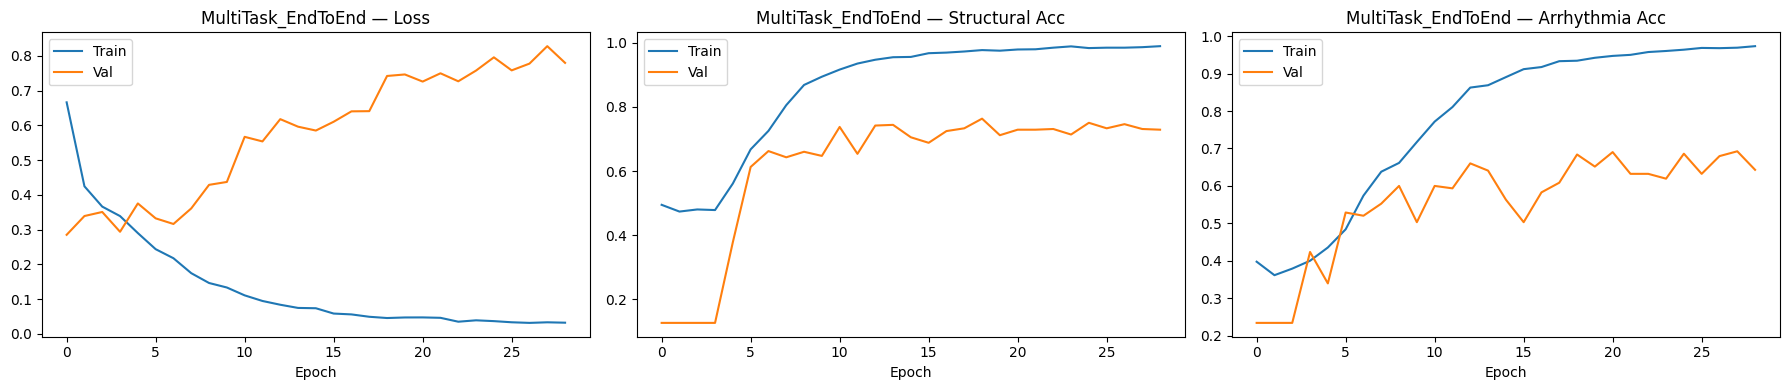

In [14]:
s2_opt = torch.optim.AdamW([
    {'params': model.echo_encoder.parameters(),              'lr': S2_LR * 0.2},
    {'params': model.ecg_encoder.parameters(),               'lr': S2_LR * 1.0},
    {'params': list(model.phase_tok.parameters()) +
               list(model.cycle_tok.parameters()) +
               list(model.fusion.parameters())   +
               list(model.head_structural.parameters()) +
               list(model.head_arrhythmia.parameters()) +
               [model.ecg_pos, model.echo_pos],              'lr': S2_LR * 1.5},
], weight_decay=5e-3)

WARMUP_EPOCHS = 3
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS * 0.1
    return 1.0

warmup_sched = torch.optim.lr_scheduler.LambdaLR(s2_opt, lr_lambda)
cosine_sched = torch.optim.lr_scheduler.CosineAnnealingLR(s2_opt, T_max=S2_EPOCHS - WARMUP_EPOCHS, eta_min=1e-6)
scaler       = torch.amp.GradScaler() if DEVICE.type == 'cuda' else None
ckpt_best    = os.path.join(OUTPUT_DIR, 'multitask_best.pt')

best_combined_f1 = 0.0
no_improve       = 0
history = {'train_loss':[], 'val_loss':[],
           'train_s_acc':[], 'val_s_acc':[],
           'train_a_acc':[], 'val_a_acc':[]}

print(f"\n{'='*70}")
print(f" Multi-task: Structural + Arrhythmia (binary × binary)")
print(f" Loss = {LAMBDA_STRUCT}×structural + {LAMBDA_ARR}×arrhythmia")
print(f" End-to-end: up to {S2_EPOCHS} epochs  |  LR={S2_LR}  |  Patience={PATIENCE}")
print(f"{'='*70}")

for ep in range(1, S2_EPOCHS + 1):
    t0 = time.time()
    tl, tsa, taa = run_epoch_mt(model, train_loader, crit_struct, crit_arr, s2_opt, scaler, use_mixup=True)
    vl, vsa, vaa = run_epoch_mt(model, val_loader,   crit_struct, crit_arr)

    if ep <= WARMUP_EPOCHS:
        warmup_sched.step()
    else:
        cosine_sched.step()

    sf1, af1, combined_f1 = compute_combined_f1(model, val_loader)

    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_s_acc'].append(tsa); history['val_s_acc'].append(vsa)
    history['train_a_acc'].append(taa); history['val_a_acc'].append(vaa)

    flag = ''
    if combined_f1 > best_combined_f1:
        best_combined_f1 = combined_f1
        no_improve = 0
        torch.save(model.state_dict(), ckpt_best)
        flag = '  <- BEST'
    else:
        no_improve += 1

    print(f"Ep {ep:03d}/{S2_EPOCHS} | "
          f"tr {tl:.3f} s={tsa:.3f} a={taa:.3f} | "
          f"val {vl:.3f} s={vsa:.3f} a={vaa:.3f} | "
          f"F1: s={sf1:.3f} a={af1:.3f} avg={combined_f1:.3f}{flag} | "
          f"{time.time()-t0:.1f}s")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {ep}")
        break

print(f"\nBest combined val F1: {best_combined_f1:.4f}")
plot_history_mt(history, 'MultiTask_EndToEnd')

## 6 · Test Set Evaluation

Loads the best checkpoint (saved by combined macro-F1) and evaluates on the held-out test set.

**Metrics reported for each task:**
- **AUROC** — threshold-independent measure of discriminative ability. 0.5 = random, 1.0 = perfect. Target: ≥ 0.80
- **AUPRC** — area under precision-recall curve. More informative than AUROC for imbalanced datasets
- **Macro F1** — harmonic mean of precision and recall, averaged across both classes equally
- **Per-class precision/recall** — critical for the minority class (normal for structural, normal rhythm for arrhythmia)

**Visualisations:**
- Confusion matrices for both tasks side by side
- ROC curves for both tasks — the gap between curves shows which task the model handles better

**Interpreting results:**
- Structural AUROC > Arrhythmia AUROC → echo branch is contributing more than ECG
- Arrhythmia AUROC > Structural AUROC → ECG branch is dominant
- Both AUROC ≥ 0.80 → strong multi-task fusion model

TEST SET RESULTS — Multi-Task Fusion Model

--- STRUCTURAL DISEASE ---
  AUROC : 0.7069
  AUPRC : 0.9382
  F1    : 0.5866
                    precision    recall  f1-score   support

            normal      0.235     0.481     0.316       108
structural_disease      0.923     0.800     0.857       844

          accuracy                          0.764       952
         macro avg      0.579     0.641     0.587       952
      weighted avg      0.845     0.764     0.796       952

--- ARRHYTHMIA ---
  AUROC : 0.6781
  AUPRC : 0.8561
  F1    : 0.6066
               precision    recall  f1-score   support

normal_rhythm      0.384     0.593     0.467       241
   arrhythmia      0.831     0.678     0.747       711

     accuracy                          0.657       952
    macro avg      0.608     0.636     0.607       952
 weighted avg      0.718     0.657     0.676       952



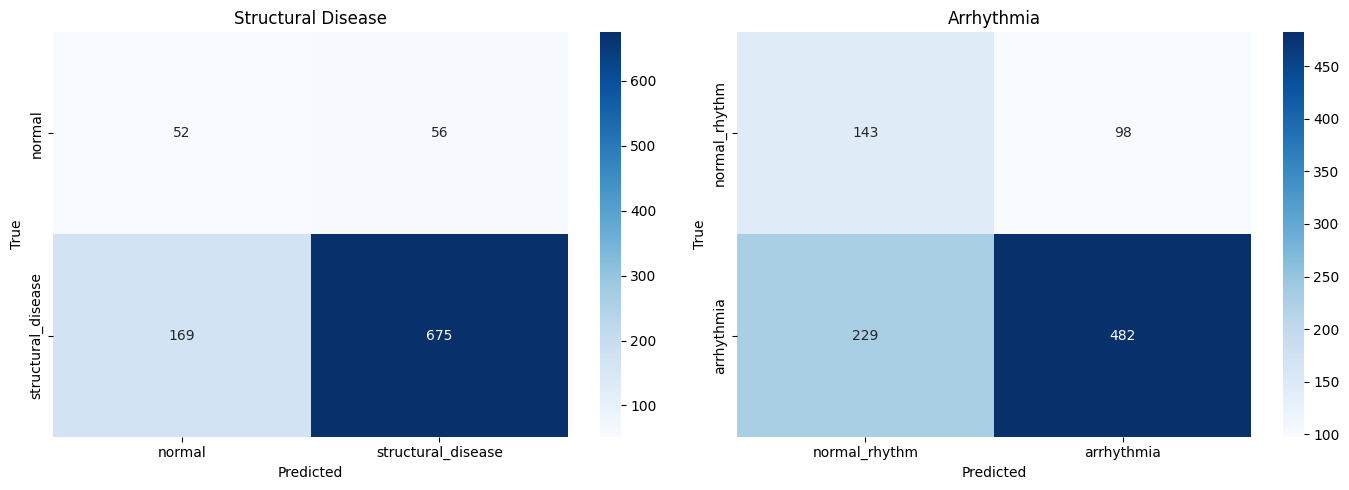

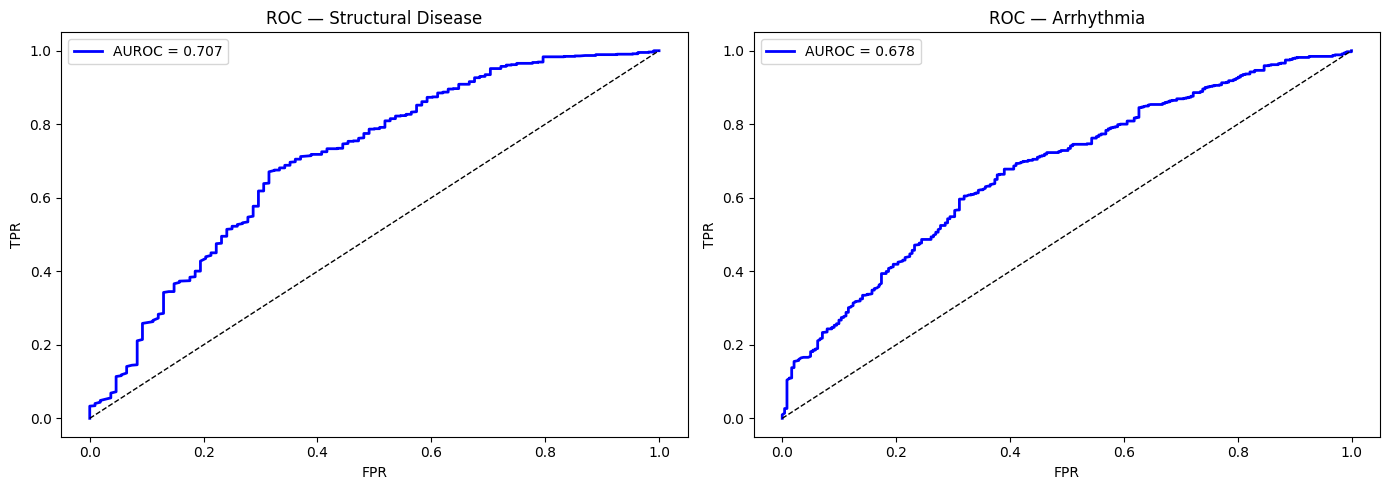


COMBINED SCORE: (structural + arrhythmia) / 2
  AUROC: 0.6925
  F1   : 0.5966


In [15]:
model.load_state_dict(torch.load(ckpt_best, map_location=DEVICE))
s_true, s_probs, a_true, a_probs = evaluate_mt(model, test_loader)

s_preds = (s_probs >= 0.5).astype(int)
a_preds = (a_probs >= 0.5).astype(int)

s_auroc = roc_auc_score(s_true, s_probs)
a_auroc = roc_auc_score(a_true, a_probs)
s_auprc = average_precision_score(s_true, s_probs)
a_auprc = average_precision_score(a_true, a_probs)
s_f1    = f1_score(s_true, s_preds, average='macro')
a_f1    = f1_score(a_true, a_preds, average='macro')

print("=" * 70)
print("TEST SET RESULTS — Multi-Task Fusion Model")
print("=" * 70)

print(f"\n--- STRUCTURAL DISEASE ---")
print(f"  AUROC : {s_auroc:.4f}")
print(f"  AUPRC : {s_auprc:.4f}")
print(f"  F1    : {s_f1:.4f}")
print(classification_report(s_true, s_preds, target_names=STRUCT_CLASSES, digits=3))

print(f"--- ARRHYTHMIA ---")
print(f"  AUROC : {a_auroc:.4f}")
print(f"  AUPRC : {a_auprc:.4f}")
print(f"  F1    : {a_f1:.4f}")
print(classification_report(a_true, a_preds, target_names=ARR_CLASSES, digits=3))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, true, preds, names, title in [
    (axes[0], s_true, s_preds, STRUCT_CLASSES, 'Structural Disease'),
    (axes[1], a_true, a_preds, ARR_CLASSES,    'Arrhythmia')
]:
    cm = confusion_matrix(true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'cm_multitask.png'), dpi=150)
plt.show()

# ROC curves — both tasks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, true, probs, auroc, title in [
    (axes[0], s_true, s_probs, s_auroc, 'Structural Disease'),
    (axes[1], a_true, a_probs, a_auroc, 'Arrhythmia')
]:
    fpr, tpr, _ = roc_curve(true, probs)
    ax.plot(fpr, tpr, 'b-', lw=2, label=f'AUROC = {auroc:.3f}')
    ax.plot([0,1], [0,1], 'k--', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title(f'ROC — {title}')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'roc_multitask.png'), dpi=150)
plt.show()

print(f"\n{'='*70}")
print(f"COMBINED SCORE: (structural + arrhythmia) / 2")
print(f"  AUROC: {(s_auroc + a_auroc) / 2:.4f}")
print(f"  F1   : {(s_f1 + a_f1) / 2:.4f}")
print(f"{'='*70}")

## 7 · XAI — Electromechanical Attribution Maps (EAM)

Visualises the **3×3 cross-attention matrix** from the last cross-attention layer, showing how ECG phase tokens attend to echo cycle tokens.

**How to read these maps:**
- Rows = ECG phase tokens (P-wave / QRS / T-wave)
- Columns = Echo cycle tokens (End-Diastole / Mid / End-Systole)
- Cell value = attention weight — how strongly the ECG phase "looks at" the echo phase
- High values indicate the model considers those two phases informationally linked

**Expected patterns:**
- **Normal patients:** sharp diagonal pattern — each ECG phase aligns cleanly with its temporal echo counterpart (P→ED, QRS→Mid, T→ES)
- **Structural disease:** diffuse attention — the normal electromechanical coupling is disrupted, so the model spreads attention across multiple phase pairs
- **Ischemic/HF patients:** high QRS→ES attention — QRS triggers ventricular contraction, and structural damage is most visible at end-systole

**Display convention:**
- Green title = correct prediction
- Red title = incorrect prediction

These maps use the **structural disease** prediction (primary task) for the true/predicted labels.

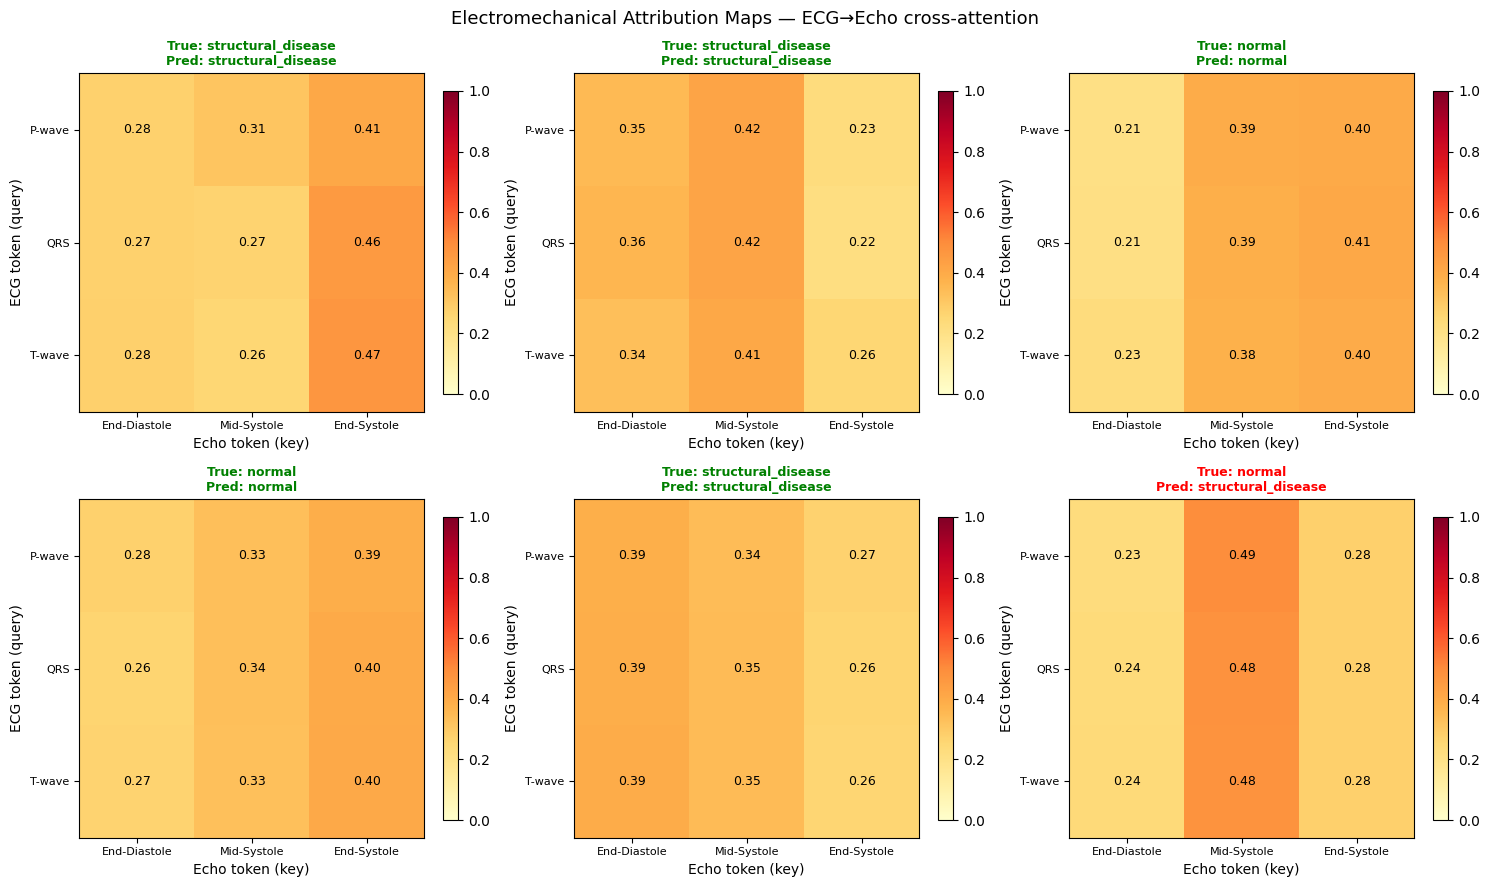

In [21]:
ECG_TOK_NAMES  = ['P-wave', 'QRS', 'T-wave']
ECHO_TOK_NAMES = ['End-Diastole', 'Mid-Systole', 'End-Systole']

def plot_eam(model, loader, num_samples=6):
    model.eval()
    collected = []
    use_amp = DEVICE.type == 'cuda'
    with torch.no_grad():
        for ecg, echo, labels, _ in loader:
            if use_amp:
                with torch.autocast('cuda', torch.float16):
                    logits, _ = model(ecg.to(DEVICE), echo.to(DEVICE))
            else:
                logits, _ = model(ecg.to(DEVICE), echo.to(DEVICE))
            preds = logits.argmax(1).cpu()
            w = model.fusion.attn_weights['ecg_to_echo'].float()  # (B, 3, 3)
            for i in range(len(labels)):
                collected.append(dict(
                    attn    = w[i].numpy(),
                    true    = STRUCT_CLASSES[labels[i]],
                    pred    = STRUCT_CLASSES[preds[i]],
                    correct = (labels[i] == preds[i]).item()
                ))
            if len(collected) >= num_samples:
                break

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for ax, s in zip(axes.flat, collected):
        im = ax.imshow(s['attn'], vmin=0, vmax=1, cmap='YlOrRd', aspect='auto')
        ax.set_xticks(range(3)); ax.set_xticklabels(ECHO_TOK_NAMES, fontsize=8)
        ax.set_yticks(range(3)); ax.set_yticklabels(ECG_TOK_NAMES,  fontsize=8)
        ax.set_xlabel('Echo token (key)');  ax.set_ylabel('ECG token (query)')
        color = 'green' if s['correct'] else 'red'
        ax.set_title(f"True: {s['true']}\nPred: {s['pred']}",
                     color=color, fontsize=9, fontweight='bold')
        for r in range(3):
            for c in range(3):
                ax.text(c, r, f"{s['attn'][r,c]:.2f}",
                        ha='center', va='center', fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.04)

    plt.suptitle('Electromechanical Attribution Maps — ECG→Echo cross-attention', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'eam_samples.png'), dpi=150)
    plt.show()


plot_eam(model, test_loader, num_samples=6)

## 8 · Save Final Checkpoint

Saves the complete model state along with task metadata, architecture config, and training history. This checkpoint is self-contained — you can reload the model anywhere with just this file and the model class definitions.

**Saved fields:**
- `model_state_dict` — all trained weights
- `struct_classes` / `arr_classes` — label names for both tasks
- `config` — architecture hyperparameters (proj_dim, attn_layers, etc.)
- `history` — training/validation loss and accuracy curves for plotting

In [22]:
final_path = os.path.join(OUTPUT_DIR, 'cardiac_fusion_final.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'struct_classes'  : STRUCT_CLASSES,
    'arr_classes'     : ARR_CLASSES,
    'config': dict(
        ecg_base_dim    = ECG_BASE_DIM,
        echo_base_dim   = ECHO_BASE_DIM,
        proj_dim        = PROJ_DIM,
        attn_heads      = ATTN_HEADS,
        attn_layers     = ATTN_LAYERS,
        num_classes_struct = NUM_CLASSES_STRUCT,
        num_classes_arr    = NUM_CLASSES_ARR,
        lambda_struct   = LAMBDA_STRUCT,
        lambda_arr      = LAMBDA_ARR,
    ),
    'history': history,
}, final_path)

print(f"Saved: {final_path}")
print("\nAll output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    mb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1e6
    print(f"  {f:45s}  {mb:7.1f} MB")

Saved: C:\Users\anwme\Desktop\Datasets\model_output\cardiac_fusion_final.pt

All output files:
  binary_best.pt                                   110.5 MB
  cardiac_fusion_final.pt                          110.4 MB
  cm_Binary_Test_Set.png                             0.0 MB
  cm_Test_Set_Fusion_Model.png                       0.1 MB
  cm_multitask.png                                   0.1 MB
  eam_samples.png                                    0.2 MB
  history_Binary_EndToEnd.png                        0.1 MB
  history_MultiTask_EndToEnd.png                     0.1 MB
  history_Stage1_Frozen.png                          0.1 MB
  history_Stage2_FineTune.png                        0.0 MB
  multitask_best.pt                                110.4 MB
  roc_multitask.png                                  0.1 MB
  roc_pr_curves.png                                  0.1 MB
  stage1_best.pt                                   110.5 MB
  stage2_best.pt                                   117.5 MB
